# CLEANING THE DATAFRAME #

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('../data/final_properties_dataset_260304.csv', sep = ',')


## Analyzing the dataset ##

In [3]:
print(df.shape)
print(df.info())
print(df.head())
print(df.tail())

(13195, 20)
<class 'pandas.DataFrame'>
RangeIndex: 13195 entries, 0 to 13194
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   URL                     13195 non-null  str    
 1   Zip code                13171 non-null  float64
 2   City                    13171 non-null  str    
 3   Type of property        13195 non-null  str    
 4   Subtype of property     13195 non-null  str    
 5   Price                   12973 non-null  float64
 6   Type of sale            13195 non-null  str    
 7   Number of rooms         12925 non-null  float64
 8   Living Area             12352 non-null  float64
 9   Fully equipped kitchen  4586 non-null   float64
 10  Furnished               8272 non-null   float64
 11  Open fire               1168 non-null   float64
 12  Terrace                 12548 non-null  float64
 13  Terrace area            5692 non-null   float64
 14  Garden                  12114 non-nul

In [4]:
df.describe(include='all')

,URL,Zip code,City,Type of property,Subtype of property,Price,Type of sale,Number of rooms,Living Area,Fully equipped kitchen,Furnished,Open fire,Terrace,Terrace area,Garden,Garden area,Surface of the land,Number of facades,Swimming pool,State of the building
count,13195,13171.000000,13171,13195,13195,1.297300e+04,13195,12925.000000,12352.000000,4586.000000,8272.000000,1168.000000,12548.000000,5692.000000,12114.000000,3006.000000,6195.000000,10300.000000,4487.000000,10379.000000
unique,13195,NaN,1420,2,15,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,https://immovlan.be/en/detail/residence/for-sa...,NaN,Ukkel,House,residence,NaN,for sale,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,1,NaN,470,7014,5911,NaN,13077,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,3871.155721,NaN,NaN,NaN,4.361525e+05,NaN,3.100812,164.565981,2.232883,0.048477,0.309075,0.780762,25.150914,0.591795,1130.354291,1252.880549,2.748350,0.090038,1.615666
std,NaN,2851.772144,NaN,NaN,NaN,5.259908e+05,NaN,17.336015,136.217282,0.705065,0.214784,0.462310,0.413747,52.496356,0.491522,13158.124785,3893.797538,0.845458,0.286268,1.400379
min,NaN,1000.000000,NaN,NaN,NaN,6.200000e+02,NaN,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000
25%,NaN,1180.000000,NaN,NaN,NaN,2.300000e+05,NaN,2.000000,91.000000,2.000000,0.000000,0.000000,1.000000,9.000000,0.000000,84.000000,224.000000,2.000000,0.000000,1.000000
50%,NaN,3090.000000,NaN,NaN,NaN,3.338530e+05,NaN,3.000000,133.000000,2.000000,0.000000,0.000000,1.000000,16.000000,1.000000,230.000000,497.000000,2.000000,0.000000,1.000000
75%,NaN,6220.000000,NaN,NaN,NaN,4.890000e+05,NaN,4.000000,195.000000,3.000000,0.000000,1.000000,1.000000,30.000000,1.000000,673.750000,1040.000000,4.000000,0.000000,2.000000


In [5]:
df.columns = [col.lower().replace(' ', '_') for col in df.columns]
print(df.columns)


Index(['url', 'zip_code', 'city', 'type_of_property', 'subtype_of_property',
       'price', 'type_of_sale', 'number_of_rooms', 'living_area',
       'fully_equipped_kitchen', 'furnished', 'open_fire', 'terrace',
       'terrace_area', 'garden', 'garden_area', 'surface_of_the_land',
       'number_of_facades', 'swimming_pool', 'state_of_the_building'],
      dtype='str')


In [6]:
# checking for duplicates
print(f'Number of duplicates: {df.duplicated().sum()}')
print()

df = df.drop_duplicates().reset_index(drop=True)

df.info()

Number of duplicates: 0

<class 'pandas.DataFrame'>
RangeIndex: 13195 entries, 0 to 13194
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   url                     13195 non-null  str    
 1   zip_code                13171 non-null  float64
 2   city                    13171 non-null  str    
 3   type_of_property        13195 non-null  str    
 4   subtype_of_property     13195 non-null  str    
 5   price                   12973 non-null  float64
 6   type_of_sale            13195 non-null  str    
 7   number_of_rooms         12925 non-null  float64
 8   living_area             12352 non-null  float64
 9   fully_equipped_kitchen  4586 non-null   float64
 10  furnished               8272 non-null   float64
 11  open_fire               1168 non-null   float64
 12  terrace                 12548 non-null  float64
 13  terrace_area            5692 non-null   float64
 14  garden                  

In [7]:
# Changing the type of data
df['zip_code'] = df['zip_code'].apply(lambda x: str(int(x)) if pd.notnull(x) else x)
df['garden_area'] = df['garden_area'].astype('Int64')

# Changing datatypes
df = df.convert_dtypes()

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 13195 entries, 0 to 13194
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   url                     13195 non-null  string
 1   zip_code                13171 non-null  string
 2   city                    13171 non-null  string
 3   type_of_property        13195 non-null  string
 4   subtype_of_property     13195 non-null  string
 5   price                   12973 non-null  Int64 
 6   type_of_sale            13195 non-null  string
 7   number_of_rooms         12925 non-null  Int64 
 8   living_area             12352 non-null  Int64 
 9   fully_equipped_kitchen  4586 non-null   Int64 
 10  furnished               8272 non-null   Int64 
 11  open_fire               1168 non-null   Int64 
 12  terrace                 12548 non-null  Int64 
 13  terrace_area            5692 non-null   Int64 
 14  garden                  12114 non-null  Int64 
 15  garden_area  

In [8]:
# cleaning spaces
subset = df.iloc[:, 0:7].select_dtypes(include=['string'])
df[subset.columns] = subset.apply(lambda x: x.str.strip())


In [9]:
# checking the percentage of missing data
print(df.isna().sum())
print("*" * 25)


for col in df.columns:
    pct_missing = np.mean(df[col].isnull())
    print('{} - {}%'.format(col, round(pct_missing*100)))

url                           0
zip_code                     24
city                         24
type_of_property              0
subtype_of_property           0
price                       222
type_of_sale                  0
number_of_rooms             270
living_area                 843
fully_equipped_kitchen     8609
furnished                  4923
open_fire                 12027
terrace                     647
terrace_area               7503
garden                     1081
garden_area               10189
surface_of_the_land        7000
number_of_facades          2895
swimming_pool              8708
state_of_the_building      2816
dtype: int64
*************************
url - 0%
zip_code - 0%
city - 0%
type_of_property - 0%
subtype_of_property - 0%
price - 2%
type_of_sale - 0%
number_of_rooms - 2%
living_area - 6%
fully_equipped_kitchen - 65%
furnished - 37%
open_fire - 91%
terrace - 5%
terrace_area - 57%
garden - 8%
garden_area - 77%
surface_of_the_land - 53%
number_of_facades - 22%
s

In [10]:
df.describe(include='all')

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
count,13195,13171,13171,13195,13195,12973.0,13195,12925.0,12352.0,4586.0,8272.0,1168.0,12548.0,5692.0,12114.0,3006.0,6195.0,10300.0,4487.0,10379.0
unique,13195,881,1420,2,15,<NA>,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
top,https://immovlan.be/en/detail/residence/for-sa...,1180,Ukkel,House,residence,<NA>,for sale,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
freq,1,470,470,7014,5911,<NA>,13077,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
mean,NaN,NaN,NaN,NaN,NaN,436152.472674,NaN,3.100812,164.565981,2.232883,0.048477,0.309075,0.780762,25.150914,0.591795,1130.354291,1252.880549,2.74835,0.090038,1.615666
std,NaN,NaN,NaN,NaN,NaN,525990.773803,NaN,17.336015,136.217282,0.705065,0.214784,0.46231,0.413747,52.496356,0.491522,13158.124785,3893.797538,0.845458,0.286268,1.400379
min,NaN,NaN,NaN,NaN,NaN,620.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
25%,NaN,NaN,NaN,NaN,NaN,230000.0,NaN,2.0,91.0,2.0,0.0,0.0,1.0,9.0,0.0,84.0,224.0,2.0,0.0,1.0
50%,NaN,NaN,NaN,NaN,NaN,333853.0,NaN,3.0,133.0,2.0,0.0,0.0,1.0,16.0,1.0,230.0,497.0,2.0,0.0,1.0
75%,NaN,NaN,NaN,NaN,NaN,489000.0,NaN,4.0,195.0,3.0,0.0,1.0,1.0,30.0,1.0,673.75,1040.0,4.0,0.0,2.0


## CLEANING THE DATAFRAME ##

In [11]:
df2 = df.copy()
df2.info()

<class 'pandas.DataFrame'>
RangeIndex: 13195 entries, 0 to 13194
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   url                     13195 non-null  string
 1   zip_code                13171 non-null  string
 2   city                    13171 non-null  string
 3   type_of_property        13195 non-null  string
 4   subtype_of_property     13195 non-null  string
 5   price                   12973 non-null  Int64 
 6   type_of_sale            13195 non-null  string
 7   number_of_rooms         12925 non-null  Int64 
 8   living_area             12352 non-null  Int64 
 9   fully_equipped_kitchen  4586 non-null   Int64 
 10  furnished               8272 non-null   Int64 
 11  open_fire               1168 non-null   Int64 
 12  terrace                 12548 non-null  Int64 
 13  terrace_area            5692 non-null   Int64 
 14  garden                  12114 non-null  Int64 
 15  garden_area  

In [12]:
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    is_in_bounds = (df[column] >= lower_bound) & (df[column] <= upper_bound)

    df_filtered = df[is_in_bounds].copy()
    df_outliers = df[~is_in_bounds].copy()

    print(f"From column '{column}' the following number of outliers {len(df_outliers)} were deleted")

    print(f"Range [{lower_bound:.2f}, {upper_bound:.2f}]")

    return df_filtered, df_outliers


In [13]:
def check_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    print(f'The number of outliers in {column} is {len(outliers)}')
    print(outliers)

In [14]:
def log_graph(df, column):
    data = df[column].dropna()

    fig, axes = plt.subplots(1, 2, figsize = (12, 5))

    skew_before = data.skew()
    sns.histplot(df[column], kde=True, ax = axes[0])
    axes[0].set_title(f'Before (Skew: {skew_before:.2f})')

    log_data = np.log1p(data)
    skew_after = log_data.skew()
    sns.histplot(log_data, kde=True, ax=axes[1], color='green')
    axes[1].set_title(f'After log1p (Skew: {skew_after:.2f})')

    plt.show()

    return {'Skew before': skew_before, 'Skew after': skew_after}

### COLUMN: Price ###

In [15]:
# checking suspicious no price
def func_no_price() -> list:
    no_price_list = df2[df2['price'].isnull()].index.tolist()
    print(f'There is(are) {len(no_price_list)} property(ies) without price. List of indices: {no_price_list}\n')
    for idx in no_price_list:
        print(f'No price is provided for the line: {idx}, URL: {df2.loc[idx, 'url']}')
    return no_price_list

In [16]:
func_no_price()

There is(are) 222 property(ies) without price. List of indices: [8, 43, 44, 110, 257, 274, 312, 344, 438, 506, 515, 617, 620, 642, 673, 690, 782, 795, 1011, 1148, 1283, 1504, 1588, 1608, 1684, 1694, 1706, 1722, 1724, 1795, 1871, 1901, 1921, 2137, 2150, 2179, 2189, 2225, 2280, 2358, 2422, 2453, 2463, 2485, 2518, 2529, 2584, 2677, 2754, 2788, 2816, 2875, 2902, 3018, 3086, 3133, 3234, 3300, 3339, 3375, 3378, 3498, 3524, 3525, 3606, 3618, 3674, 3690, 3699, 3728, 3755, 3768, 3806, 3822, 3823, 3899, 3989, 4030, 4156, 4209, 4364, 4383, 4416, 4447, 4471, 4528, 4586, 4602, 4609, 4625, 4691, 4721, 4843, 4869, 4898, 5073, 5077, 5137, 5275, 5293, 5317, 5329, 5359, 5380, 5525, 5600, 5949, 5959, 5977, 5996, 6102, 6215, 6239, 6264, 6292, 6436, 6525, 6636, 6730, 6774, 6782, 6871, 6936, 7064, 7069, 7079, 7083, 7090, 7147, 7154, 7163, 7168, 7367, 7422, 7561, 7569, 7583, 7594, 7607, 7723, 7760, 7860, 7877, 7926, 8003, 8012, 8017, 8155, 8164, 8232, 8237, 8242, 8321, 8368, 8374, 8386, 8396, 8638, 8697, 870

[8,
 43,
 44,
 110,
 257,
 274,
 312,
 344,
 438,
 506,
 515,
 617,
 620,
 642,
 673,
 690,
 782,
 795,
 1011,
 1148,
 1283,
 1504,
 1588,
 1608,
 1684,
 1694,
 1706,
 1722,
 1724,
 1795,
 1871,
 1901,
 1921,
 2137,
 2150,
 2179,
 2189,
 2225,
 2280,
 2358,
 2422,
 2453,
 2463,
 2485,
 2518,
 2529,
 2584,
 2677,
 2754,
 2788,
 2816,
 2875,
 2902,
 3018,
 3086,
 3133,
 3234,
 3300,
 3339,
 3375,
 3378,
 3498,
 3524,
 3525,
 3606,
 3618,
 3674,
 3690,
 3699,
 3728,
 3755,
 3768,
 3806,
 3822,
 3823,
 3899,
 3989,
 4030,
 4156,
 4209,
 4364,
 4383,
 4416,
 4447,
 4471,
 4528,
 4586,
 4602,
 4609,
 4625,
 4691,
 4721,
 4843,
 4869,
 4898,
 5073,
 5077,
 5137,
 5275,
 5293,
 5317,
 5329,
 5359,
 5380,
 5525,
 5600,
 5949,
 5959,
 5977,
 5996,
 6102,
 6215,
 6239,
 6264,
 6292,
 6436,
 6525,
 6636,
 6730,
 6774,
 6782,
 6871,
 6936,
 7064,
 7069,
 7079,
 7083,
 7090,
 7147,
 7154,
 7163,
 7168,
 7367,
 7422,
 7561,
 7569,
 7583,
 7594,
 7607,
 7723,
 7760,
 7860,
 7877,
 7926,
 8003,
 8012,


In [17]:
df2.dropna(subset=['price'], inplace = True)

<Axes: ylabel='price'>

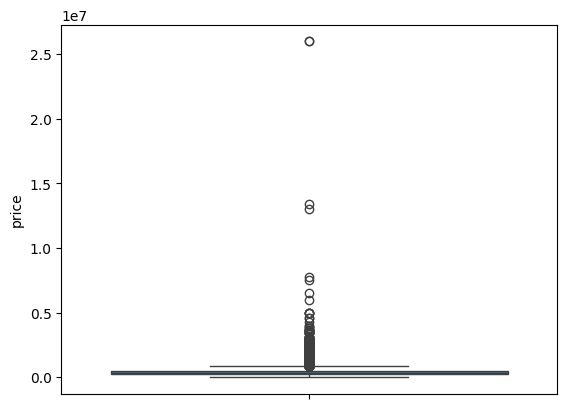

In [18]:
sns.boxplot(y=df['price'])

In [19]:
check_outliers(df2, 'price')

The number of outliers in price is 924
                                                     url zip_code  \
4      https://immovlan.be/en/detail/villa/for-sale/1...     1780   
18     https://immovlan.be/en/detail/residence/for-sa...     1440   
22     https://immovlan.be/en/detail/penthouse/for-sa...     1150   
36     https://immovlan.be/en/detail/villa/for-sale/1...     1150   
41     https://immovlan.be/en/detail/residence/for-sa...     1000   
...                                                  ...      ...   
13160  https://immovlan.be/en/detail/penthouse/for-sa...     1000   
13162  https://immovlan.be/en/detail/villa/for-sale/1...     1460   
13167  https://immovlan.be/en/detail/apartment/for-sa...     1050   
13180  https://immovlan.be/en/detail/master-house/for...     1180   
13190  https://immovlan.be/en/detail/residence/for-sa...     1180   

                      city type_of_property subtype_of_property    price  \
4                   Wemmel            House             

In [20]:
df2.sort_values(by='price', ascending=False).head(5)

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
10191,https://immovlan.be/en/detail/mixed-building/f...,5500,Dinant,House,mixed-building,26000000,for sale,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
6132,https://immovlan.be/en/detail/mixed-building/f...,6000,Charleroi,House,mixed-building,26000000,for sale,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2,<NA>,<NA>
10739,https://immovlan.be/en/detail/residence/for-sa...,1000,Brussels,House,residence,13400000,for sale,50,2700,<NA>,0,<NA>,0,<NA>,0,<NA>,769,<NA>,<NA>,2
9495,https://immovlan.be/en/detail/residence/for-sa...,1000,Brussels,House,residence,13000000,for sale,100,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,<NA>,<NA>
4588,https://immovlan.be/en/detail/residence/for-sa...,1000,Brussels,House,residence,7750000,for sale,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,<NA>,<NA>


In [21]:
df2.sort_values(by='price', ascending=False).tail(5)

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
7933,https://immovlan.be/en/detail/residence/in-pub...,4420,Saint-Nicolas,House,residence,20000,in public sale,2,60,<NA>,<NA>,<NA>,0,<NA>,1,<NA>,110,2,<NA>,0
12842,https://immovlan.be/en/detail/bungalow/for-sal...,5540,Hastière-Lavaux,Apartment,bungalow,19000,for sale,1,49,<NA>,0,<NA>,1,15,1,200,242,<NA>,<NA>,0
11751,https://immovlan.be/en/detail/chalet/in-public...,5541,Hastière-par-delà,Apartment,chalet,10000,in public sale,1,54,<NA>,<NA>,<NA>,1,<NA>,0,<NA>,56,2,<NA>,0
6416,https://immovlan.be/en/detail/residence/for-sa...,5670,Mazée,House,residence,1100,for sale,3,255,<NA>,<NA>,<NA>,0,<NA>,1,169,374,3,<NA>,<NA>
12117,https://immovlan.be/en/detail/residence/for-sa...,5660,Mariembourg,House,residence,620,for sale,1,72,<NA>,<NA>,<NA>,0,<NA>,1,800,895,4,<NA>,<NA>


In [22]:
print(f"Maximum price url: {df2.loc[df2['price'].idxmax(), 'url']}, index: {df2['price'].idxmax()}")
print(f"Minimum price url: {df2.loc[df2['price'].idxmin(), 'url']}, index: {df2['price'].idxmin()}")

Maximum price url: https://immovlan.be/en/detail/mixed-building/for-sale/6000/charleroi/vbd70032, index: 6132
Minimum price url: https://immovlan.be/en/detail/residence/for-sale/5660/mariembourg/vbd84667, index: 12117


### COLUMN: Zip code ###

In [23]:
df2['zip_code'].describe()

count     12973
unique      881
top        1180
freq        467
Name: zip_code, dtype: object

In [24]:
# checking susoicious no zip code
def func_no_zip():
    no_zip_list = df2[df2['zip_code'].isnull()].index.tolist()
    print(f"There are {len(no_zip_list)} properties without zip\n")
    print(f'Indices of the property without zip code are: {no_zip_list}')
    for idx in no_zip_list:
        print(f'No index is provided for the line: {idx}, URL: {df2.loc[idx, 'url']}')

In [25]:
func_no_zip()

There are 0 properties without zip

Indices of the property without zip code are: []


### COLUMN: City ###

In [26]:
df2['city'].describe()

count     12973
unique     1417
top       Ukkel
freq        467
Name: city, dtype: object

### COLUMN: Number of rooms ###

<Axes: ylabel='number_of_rooms'>

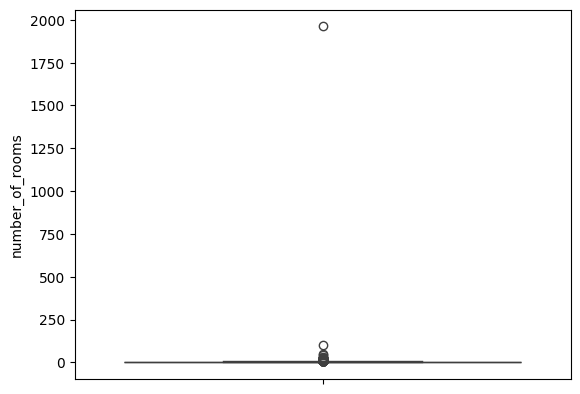

In [27]:
sns.boxplot(y=df2['number_of_rooms'])

In [28]:
# checking susoicious max room number
def func_max_rooms():
    max_rooms = df2['number_of_rooms'].idxmax()
    print(f'index of the property with maximum number of rooms is: {max_rooms}, data: {df2.loc[max_rooms, 'number_of_rooms']}')

    print(f"{df2.loc[max_rooms, 'url']}")

In [29]:
func_max_rooms()

index of the property with maximum number of rooms is: 3499, data: 1962
https://immovlan.be/en/detail/residence/for-sale/1880/nieuwenrode/rbv11758


In [30]:
df2.loc[3499, 'number_of_rooms'] = 4


In [31]:
df2['number_of_rooms'].describe()

count     12729.0
mean     2.946736
std      1.896229
min           0.0
25%           2.0
50%           3.0
75%           4.0
max         100.0
Name: number_of_rooms, dtype: Float64

<Axes: ylabel='number_of_rooms'>

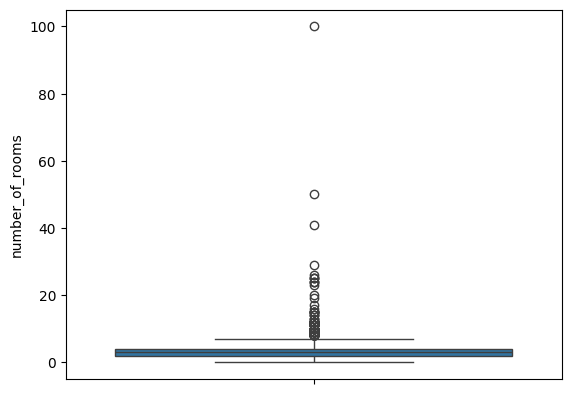

In [32]:
sns.boxplot(y=df2['number_of_rooms'])

In [33]:
df2.sort_values(by='number_of_rooms', ascending=False).head(5)

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
9495,https://immovlan.be/en/detail/residence/for-sa...,1000,Brussels,House,residence,13000000,for sale,100,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,4,<NA>,<NA>
10739,https://immovlan.be/en/detail/residence/for-sa...,1000,Brussels,House,residence,13400000,for sale,50,2700,<NA>,0,<NA>,0,<NA>,0,<NA>,769,<NA>,<NA>,2
9741,https://immovlan.be/en/detail/mansion/for-sale...,5080,Rhisnes,Apartment,mansion,1499000,for sale,41,<NA>,<NA>,0,<NA>,1,<NA>,0,<NA>,6000,4,<NA>,4
7191,https://immovlan.be/en/detail/residence/for-sa...,5660,Aublain,House,residence,990000,for sale,29,2350,<NA>,0,0,0,<NA>,0,<NA>,17470,<NA>,<NA>,<NA>
12749,https://immovlan.be/en/detail/residence/for-sa...,6940,Barvaux-sur-Ourthe,House,residence,1190000,for sale,26,1280,2,1,<NA>,1,85,1,<NA>,10808,4,<NA>,1


In [34]:
check_outliers(df2, 'number_of_rooms')

The number of outliers in number_of_rooms is 149
                                                     url zip_code  \
181    https://immovlan.be/en/detail/residence/for-sa...     1000   
751    https://immovlan.be/en/detail/mansion/for-sale...     9080   
787    https://immovlan.be/en/detail/residence/for-sa...     1460   
806    https://immovlan.be/en/detail/residence/for-sa...     1160   
1022   https://immovlan.be/en/detail/mixed-building/f...     7700   
...                                                  ...      ...   
12676  https://immovlan.be/en/detail/residence/for-sa...     6680   
12742  https://immovlan.be/en/detail/residence/for-sa...     1040   
12749  https://immovlan.be/en/detail/residence/for-sa...     6940   
12872  https://immovlan.be/en/detail/apartment/for-sa...     8480   
13102  https://immovlan.be/en/detail/residence/for-sa...     4030   

                     city type_of_property subtype_of_property    price  \
181              Brussels            House     

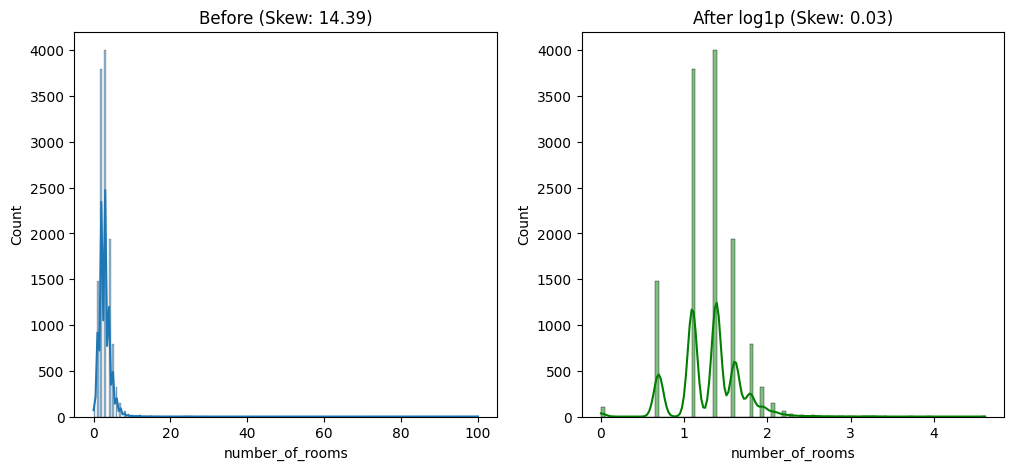

{'Skew before': np.float64(14.390361114091963),
 'Skew after': np.float64(0.02901518679937925)}

In [35]:
log_graph(df2,'number_of_rooms')

### COLUMN: Living area ###

<Axes: ylabel='living_area'>

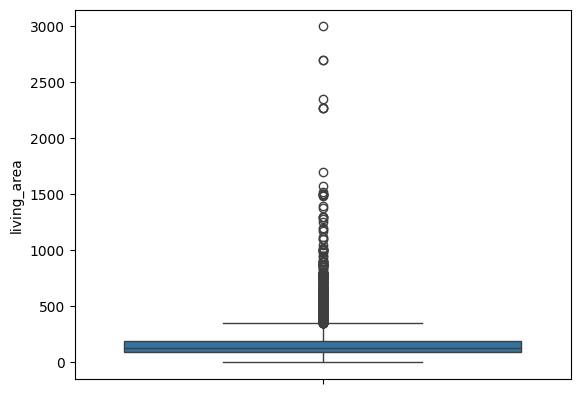

In [36]:
sns.boxplot(y = df2['living_area'])

In [37]:
# checking suspicious min living area number
def func_min_living_area():
    min_living_area = df2['living_area'].idxmin()
    print(f'index of the property with minimum living area is: {min_living_area}, data: {df2.loc[min_living_area, 'living_area']}')

    print(f"{df2.loc[min_living_area, 'url']}")

In [38]:
func_min_living_area()

index of the property with minimum living area is: 192, data: 1
https://immovlan.be/en/detail/residence/for-sale/4821/andrimont/vwd16705


In [39]:
df2.sort_values(by='living_area', ascending=False).head(10)

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
4251,https://immovlan.be/en/detail/mansion/for-sale...,3806,Velm,Apartment,mansion,2450000,for sale,20,3000,<NA>,0,<NA>,0,<NA>,1,<NA>,64254,4,1,<NA>
10739,https://immovlan.be/en/detail/residence/for-sa...,1000,Brussels,House,residence,13400000,for sale,50,2700,<NA>,0,<NA>,0,<NA>,0,<NA>,769,<NA>,<NA>,2
2746,https://immovlan.be/en/detail/mixed-building/f...,1030,Schaarbeek,House,mixed-building,1725000,for sale,6,2700,<NA>,<NA>,<NA>,1,<NA>,<NA>,<NA>,950,3,0,1
7191,https://immovlan.be/en/detail/residence/for-sa...,5660,Aublain,House,residence,990000,for sale,29,2350,<NA>,0,0,0,<NA>,0,<NA>,17470,<NA>,<NA>,<NA>
11277,https://immovlan.be/en/detail/residence/for-sa...,5500,Dinant,House,residence,1850000,for sale,7,2274,2,0,<NA>,1,100,1,28500,29205,4,0,1
7393,https://immovlan.be/en/detail/residence/for-sa...,5522,Falaën,House,residence,1850000,for sale,7,2274,2,0,<NA>,1,100,1,28500,29205,4,0,1
10849,https://immovlan.be/en/detail/residence/for-sa...,5537,Denée,House,residence,1850000,for sale,7,2274,<NA>,0,<NA>,0,<NA>,1,20000,29205,4,0,1
11238,https://immovlan.be/en/detail/mansion/for-sale...,9961,Boekhoute,Apartment,mansion,2698000,for sale,9,1699,3,0,<NA>,1,275,1,16500,65193,4,0,2
6202,https://immovlan.be/en/detail/residence/for-sa...,6970,Tenneville,House,residence,200000,for sale,3,1579,2,0,<NA>,1,<NA>,1,<NA>,<NA>,4,<NA>,0
12615,https://immovlan.be/en/detail/apartment/for-sa...,5060,Auvelais,Apartment,apartment,590000,for sale,3,1517,<NA>,0,<NA>,1,<NA>,0,<NA>,<NA>,4,<NA>,<NA>


In [40]:
df2_small_living_area = df2[(df2['living_area'] < 10) & (df2['living_area'] > 0)]
df2_small_living_area.describe()
#df2.sort_values(by='living_area', ascending=False).tail(10)

,price,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
count,15.0,15.0,15.0,10.0,0.0,3.0,5.0,0.0,11.0,1.0,14.0,11.0,1.0,13.0
mean,432233.333333,2.733333,1.266667,2.1,<NA>,1.0,0.8,<NA>,1.0,625.0,2078.571429,3.727273,1.0,1.384615
std,406616.686234,1.162919,1.032796,0.737865,<NA>,0.0,0.447214,<NA>,0.0,<NA>,3936.654548,0.64667,<NA>,1.043908
min,154000.0,1.0,1.0,1.0,<NA>,1.0,0.0,<NA>,1.0,625.0,34.0,2.0,1.0,0.0
25%,206500.0,2.0,1.0,2.0,<NA>,1.0,1.0,<NA>,1.0,625.0,367.5,4.0,1.0,1.0
50%,349350.0,3.0,1.0,2.0,<NA>,1.0,1.0,<NA>,1.0,625.0,836.5,4.0,1.0,1.0
75%,385550.0,3.0,1.0,2.75,<NA>,1.0,1.0,<NA>,1.0,625.0,1692.75,4.0,1.0,2.0
max,1620000.0,5.0,5.0,3.0,<NA>,1.0,1.0,<NA>,1.0,625.0,15130.0,4.0,1.0,4.0


In [41]:
df2['living_area'].describe()

count       12181.0
mean     163.649782
std      134.782079
min             1.0
25%            90.0
50%           132.0
75%           194.0
max          3000.0
Name: living_area, dtype: Float64

In [42]:
check_outliers(df2,'living_area')

The number of outliers in living_area is 693
                                                     url zip_code  \
2      https://immovlan.be/en/detail/residence/for-sa...     7850   
4      https://immovlan.be/en/detail/villa/for-sale/1...     1780   
15     https://immovlan.be/en/detail/residence/for-sa...     6800   
25     https://immovlan.be/en/detail/residence/for-sa...     9630   
36     https://immovlan.be/en/detail/villa/for-sale/1...     1150   
...                                                  ...      ...   
13120  https://immovlan.be/en/detail/mixed-building/f...     5060   
13127  https://immovlan.be/en/detail/residence/for-sa...     2800   
13147  https://immovlan.be/en/detail/mixed-building/f...     1030   
13155  https://immovlan.be/en/detail/residence/for-sa...     1150   
13167  https://immovlan.be/en/detail/apartment/for-sa...     1050   

                      city type_of_property subtype_of_property    price  \
2                  Enghien            House       

### COLUMN: Fully equiped kitchen ###

In [43]:
df2['fully_equipped_kitchen'].describe()

count      4536.0
mean     2.233245
std      0.705816
min           0.0
25%           2.0
50%           2.0
75%           3.0
max           3.0
Name: fully_equipped_kitchen, dtype: Float64

### COLUMN: Furnished ###

In [44]:
df2['furnished'].describe()

count      8155.0
mean      0.04905
std      0.215985
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           1.0
Name: furnished, dtype: Float64

### COLUMN: Open fire ###

In [45]:
df2['open_fire'].describe()

count      1164.0
mean      0.30756
std      0.461682
min           0.0
25%           0.0
50%           0.0
75%           1.0
max           1.0
Name: open_fire, dtype: Float64

### COLUMN: Terrace ###

In [46]:
df2['terrace'].describe()

count     12352.0
mean     0.780278
std      0.414075
min           0.0
25%           1.0
50%           1.0
75%           1.0
max           1.0
Name: terrace, dtype: Float64

### COLUMN: Terrace area ###

<Axes: ylabel='terrace_area'>

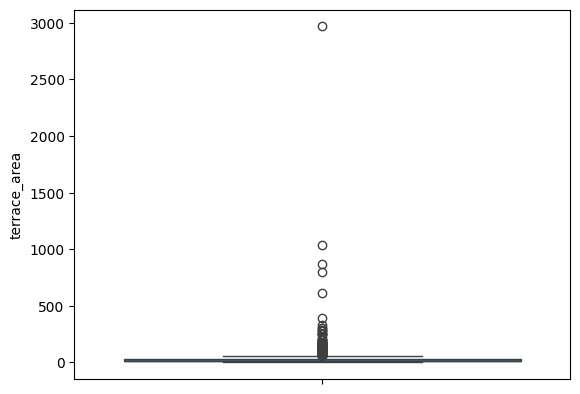

In [47]:
sns.boxplot(y=df2['terrace_area'])

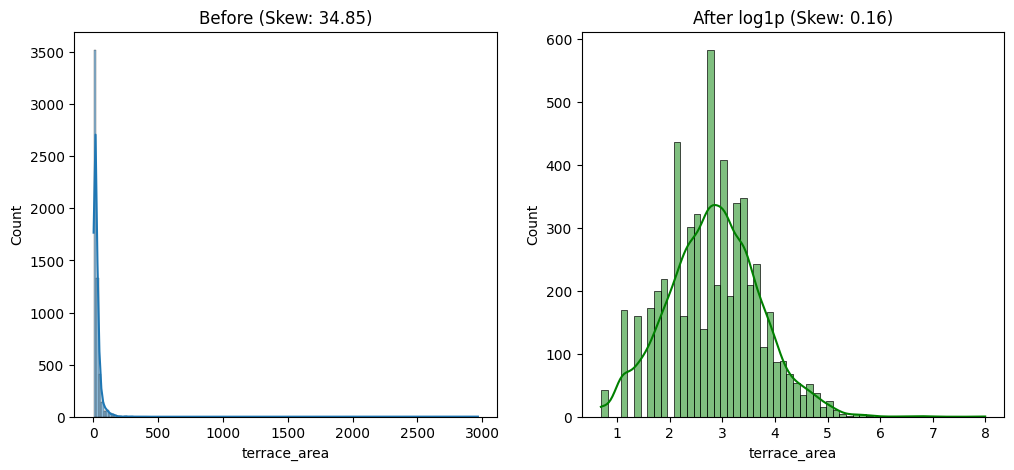

{'Skew before': np.float64(34.85364409010952),
 'Skew after': np.float64(0.16124793047174207)}

In [48]:
log_graph(df2, 'terrace_area')

In [49]:
# checking suspicious terrace area size
def func_max_terrace_area():
    max_terrace_area = df2['terrace_area'].idxmax()
    print(f'Index of the property with maximum terrace area size is: {max_terrace_area}, data: {df2.loc[max_terrace_area, 'terrace_area']}')

    print(f"{df2.loc[max_terrace_area, 'url']}")

In [50]:
func_max_terrace_area()

Index of the property with maximum terrace area size is: 1199, data: 2968
https://immovlan.be/en/detail/residence/for-sale/6950/harsin/vbd88226


In [51]:
#deleting the row after ionspecting the property

df2.drop(index=1199, inplace=True)

In [52]:
df2['terrace_area'].describe()

count       5616.0
mean     24.498041
std      34.756679
min            1.0
25%            9.0
50%           16.0
75%           30.0
max         1040.0
Name: terrace_area, dtype: Float64

In [53]:
func_max_terrace_area()

Index of the property with maximum terrace area size is: 4856, data: 1040
https://immovlan.be/en/detail/residence/for-sale/1390/grez-doiceau/vbd23636


### COLUMN: Garden ###

In [54]:
df2['garden'].describe()

count     11920.0
mean     0.589849
std      0.491882
min           0.0
25%           0.0
50%           1.0
75%           1.0
max           1.0
Name: garden, dtype: Float64

### COLUMN: Garden area ###

In [55]:
df2['garden_area'].describe()

count          2952.0
mean       1095.10061
std      13185.590866
min               1.0
25%              83.0
50%             225.5
75%             655.5
max          690330.0
Name: garden_area, dtype: Float64

<Axes: ylabel='garden_area'>

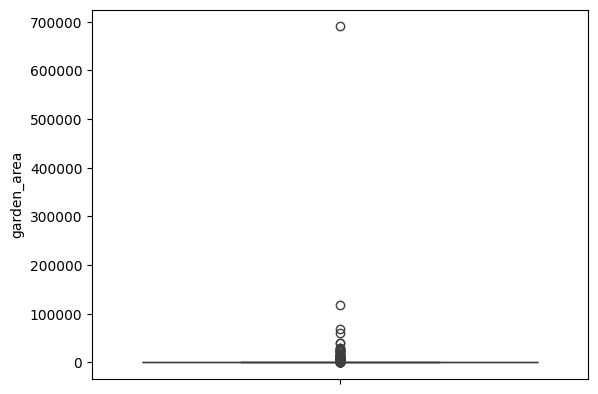

In [56]:
sns.boxplot(y=df2['garden_area'])

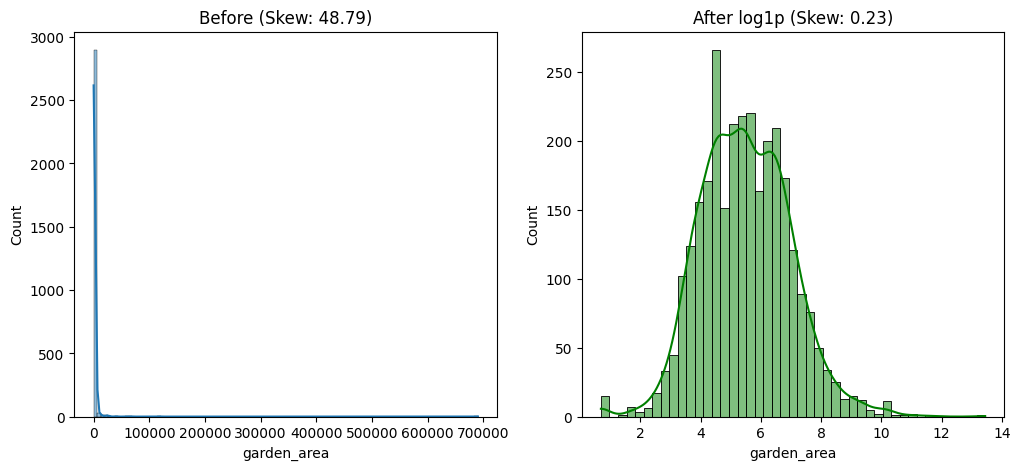

{'Skew before': np.float64(48.79319977609717),
 'Skew after': np.float64(0.23018640898366904)}

In [57]:
log_graph(df2, 'garden_area')

In [58]:
# checking suspicious garden size
def func_max_garden_area():
    max_garden = df2['garden_area'].idxmax()
    print(f'index of the property with maximum garden area size is: {max_garden}, data: {df2.loc[max_garden, 'garden_area']}')

    print(f"{df2.loc[max_garden, 'url']}")

In [59]:
func_max_garden_area()

index of the property with maximum garden area size is: 8745, data: 690330
https://immovlan.be/en/detail/residence/for-sale/1130/haren/vbd76660


In [60]:
# n_garden_area_missing = df2['Garden area'].isnull().sum()
# print(f"Number of missing data on garden area: {n_garden_area_missing}")

# garden_area_mean_old = df2['Garden area'].mean()
# print(f"The garden area mean BEFORE fillna: {garden_area_mean_old}")
# garden_area_mode = df2['Garden area'].mode()[0]
# print(f"The garden area mode: {garden_area_mode}")


In [61]:
df2.loc[8745, 'garden_area'] = 690


<Axes: ylabel='garden_area'>

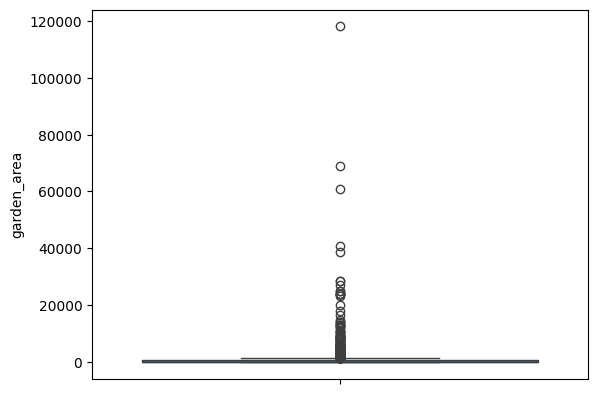

In [62]:
sns.boxplot(y=df2['garden_area'])

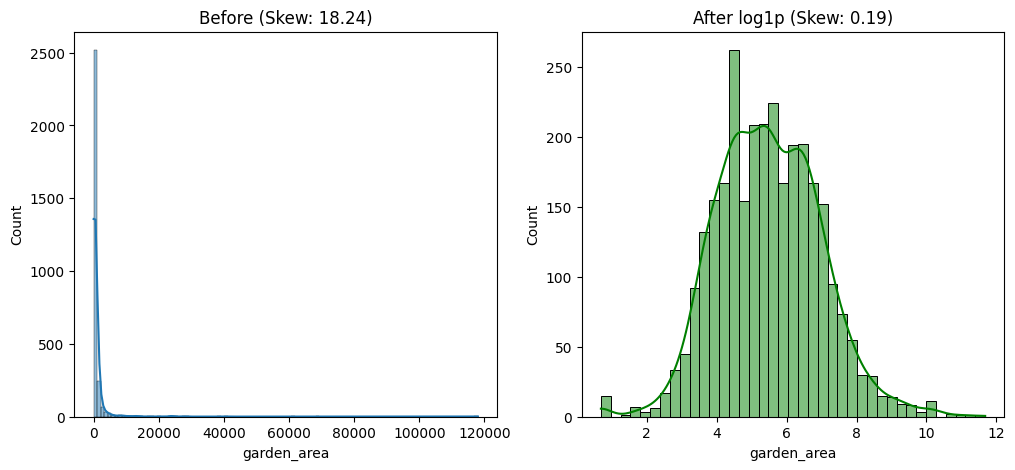

{'Skew before': np.float64(18.242729357307518),
 'Skew after': np.float64(0.1857231761928229)}

In [63]:
log_graph(df2, 'garden_area')

In [64]:
df2.sort_values(by='garden_area', ascending=False).head(5)

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
8025,https://immovlan.be/en/detail/residence/for-sa...,6900,Marche-en-Famenne,House,residence,1200000,for sale,8,514,<NA>,<NA>,<NA>,1,70,1,118000,101895,4,0,0
8792,https://immovlan.be/en/detail/villa/for-sale/1...,1380,Lasne,House,villa,2900000,for sale,6,450,2,0,<NA>,1,20,1,69000,70000,4,1,0
7613,https://immovlan.be/en/detail/villa/for-sale/3...,3000,Leuven,House,villa,1590000,for sale,4,488,1,<NA>,1,<NA>,<NA>,1,61000,<NA>,4,<NA>,1
2050,https://immovlan.be/en/detail/villa/for-sale/6...,6870,Saint-Hubert,House,villa,1950000,for sale,4,790,<NA>,<NA>,<NA>,1,200,1,40730,42025,4,1,2
9293,https://immovlan.be/en/detail/residence/for-sa...,5530,Yvoir,House,residence,850000,for sale,5,198,2,<NA>,<NA>,1,21,1,38887,4097,4,1,2


In [65]:
df2['garden_area'].describe()

count         2952.0
mean      861.482724
std      3581.580306
min              1.0
25%             83.0
50%            225.5
75%            655.5
max         118000.0
Name: garden_area, dtype: Float64

In [66]:
func_max_garden_area()

index of the property with maximum garden area size is: 8025, data: 118000
https://immovlan.be/en/detail/residence/for-sale/6900/marche-en-famenne/vbd16284


In [67]:
# df.fillna({'garden_area': 0}, inplace=True)

In [68]:
# garden_area_mean_new = df2['Garden area'].mean()
# print(f"The garden area mean AFTER fillna: {garden_area_mean_new}")

### COLUMN: Surface of the land ###

<Axes: ylabel='surface_of_the_land'>

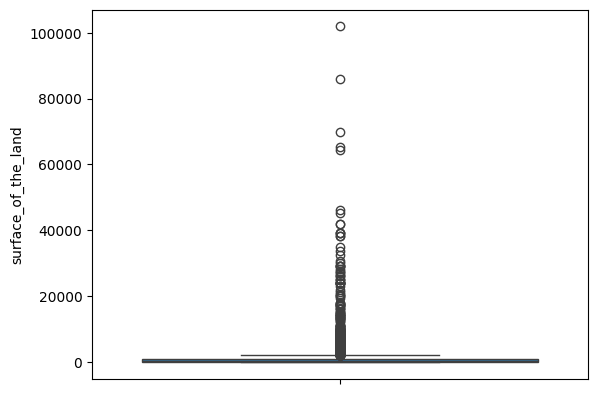

In [69]:
sns.boxplot(y=df2['surface_of_the_land'])

In [70]:
# checking suspicious surface of the land size
def func_max_land_size():
    max_land_size = df2['surface_of_the_land'].idxmax()
    print(f'index of the property with maximum land size is: {max_land_size}, data: {df2.loc[max_land_size, 'surface_of_the_land']}')

    print(f"{df2.loc[max_land_size, 'url']}")

In [71]:
func_max_land_size()

index of the property with maximum land size is: 8025, data: 101895
https://immovlan.be/en/detail/residence/for-sale/6900/marche-en-famenne/vbd16284


Found the link:  https://immovlan.be/en/detail/residence/for-sale/6900/marche-en-famenne/vbd16284

Why the the 'surface garden' (118000) is BIGGER than 'total land surface' (101895)?

In [72]:
df2['surface_of_the_land'].describe()

count        6085.0
mean     1210.62728
std      3657.33207
min             1.0
25%           224.0
50%           494.0
75%          1030.0
max        101895.0
Name: surface_of_the_land, dtype: Float64

In [73]:
df2.sort_values(by='surface_of_the_land', ascending=False).head(5)

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
8025,https://immovlan.be/en/detail/residence/for-sa...,6900,Marche-en-Famenne,House,residence,1200000,for sale,8,514,<NA>,<NA>,<NA>,1,70,1,118000,101895,4,0,0
1471,https://immovlan.be/en/detail/villa/for-sale/1...,1380,Lasne,House,villa,1675000,for sale,6,614,2,0,<NA>,1,150,1,8300,86000,4,1,0
8792,https://immovlan.be/en/detail/villa/for-sale/1...,1380,Lasne,House,villa,2900000,for sale,6,450,2,0,<NA>,1,20,1,69000,70000,4,1,0
11238,https://immovlan.be/en/detail/mansion/for-sale...,9961,Boekhoute,Apartment,mansion,2698000,for sale,9,1699,3,0,<NA>,1,275,1,16500,65193,4,0,2
4251,https://immovlan.be/en/detail/mansion/for-sale...,3806,Velm,Apartment,mansion,2450000,for sale,20,3000,<NA>,0,<NA>,0,<NA>,1,<NA>,64254,4,1,<NA>


### COLUMN: Number of facades ###

<Axes: ylabel='number_of_facades'>

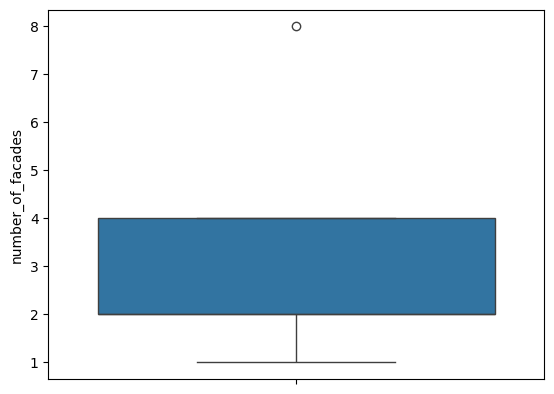

In [74]:
sns.boxplot(y=df2['number_of_facades'])

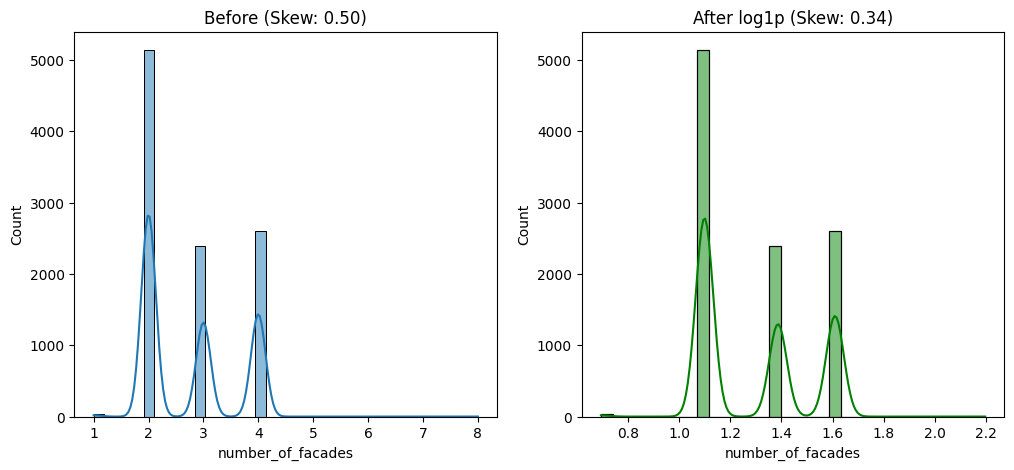

{'Skew before': np.float64(0.49702123476855004),
 'Skew after': np.float64(0.3356483129885848)}

In [75]:
log_graph(df2, 'number_of_facades')

In [76]:
# checking suspicious number of facades
def func_max_facade_number():
    max_facade_number = df2['number_of_facades'].idxmax()
    print(f'index of the property with maximum number of facades is: {max_facade_number}, data: {df2.loc[max_facade_number, 'number_of_facades']}')

    print(f"{df2.loc[max_facade_number, 'url']}")

In [77]:
func_max_facade_number()

index of the property with maximum number of facades is: 7080, data: 8
https://immovlan.be/en/detail/residence/for-sale/1000/brussels/vbd93085


In [78]:
# Cleaned the property facades
df2.loc[7080, 'number_of_facades'] = 2


In [79]:
df2['number_of_facades'].describe(include='all')

count     10171.0
mean     2.743978
std      0.842184
min           1.0
25%           2.0
50%           2.0
75%           4.0
max           4.0
Name: number_of_facades, dtype: Float64

### COLUMN:  Swimming pool ###

In [80]:
df2['swimming_pool'].describe()

# Filling Nan with 0
#df['Swimming pool'] = df['Swimming pool'].fillna(0) 

count      4414.0
mean     0.088355
std      0.283843
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           1.0
Name: swimming_pool, dtype: Float64

In [81]:
df2['swimming_pool'].value_counts()

swimming_pool
0    4024
1     390
Name: count, dtype: Int64

In [82]:
df2['swimming_pool'].value_counts(normalize=True) * 100

swimming_pool
0    91.164477
1     8.835523
Name: proportion, dtype: Float64

### COLUMN: State of the building ###

In [83]:

df2['state_of_the_building'].describe()


count     10219.0
mean     1.610236
std      1.396896
min           0.0
25%           1.0
50%           1.0
75%           2.0
max           4.0
Name: state_of_the_building, dtype: Float64

In [84]:
df2.describe(include='all')

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building
count,12972,12972,12972,12972,12972,12972.0,12972,12728.0,12180.0,4536.0,8154.0,1164.0,12351.0,5616.0,11920.0,2952.0,6085.0,10171.0,4414.0,10219.0
unique,12972,881,1417,2,15,<NA>,2,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
top,https://immovlan.be/en/detail/residence/for-sa...,1180,Ukkel,House,residence,<NA>,for sale,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
freq,1,467,467,6901,5810,<NA>,12854,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
mean,NaN,NaN,NaN,NaN,NaN,436159.191181,NaN,2.946653,163.652545,2.233245,0.049056,0.30756,0.780261,24.498041,0.589849,861.482724,1210.62728,2.743978,0.088355,1.610236
std,NaN,NaN,NaN,NaN,NaN,526010.49239,NaN,1.896281,134.787268,0.705816,0.215998,0.461682,0.414087,34.756679,0.491882,3581.580306,3657.33207,0.842184,0.283843,1.396896
min,NaN,NaN,NaN,NaN,NaN,620.0,NaN,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0
25%,NaN,NaN,NaN,NaN,NaN,230000.0,NaN,2.0,90.0,2.0,0.0,0.0,1.0,9.0,0.0,83.0,224.0,2.0,0.0,1.0
50%,NaN,NaN,NaN,NaN,NaN,333786.5,NaN,3.0,132.0,2.0,0.0,0.0,1.0,16.0,1.0,225.5,494.0,2.0,0.0,1.0
75%,NaN,NaN,NaN,NaN,NaN,489000.0,NaN,4.0,194.0,3.0,0.0,1.0,1.0,30.0,1.0,655.5,1030.0,4.0,0.0,2.0


## Assigning values ##

In [ ]:
def convert_categorical_columns(df, column_name, prefix):
    # Convert the column into binary columns
    column_dummies = pd.get_dummies(df[column_name], prefix=prefix)

    # Join these new columns back to your original dataframe
    return pd.concat([df, column_dummies], axis=1)


def convert_columns_data_type(df, column_name, data_type):
    if data_type == bool:
        # Fill empty cells with 0, then convert to boolean
        df[column_name] = df[column_name].fillna(0).astype(bool)
    df[column_name] = df[column_name].astype(data_type)


def get_correlation_matrix(df, column_name):
    # Calculate correlation only for numeric columns (integers and floats)
    correlations = df.corr(numeric_only=True)[column_name].sort_values(ascending=False)

    print('*' * 50)
    print(f"Correlation with {column_name}:")
    print(correlations)

In [109]:
# Assigning numeric value to the 'string' data
df3 = df2.copy()


# Matching zip codes to Provinces
def classify_region(zipcode):
    prefix = int(str(zipcode)[:2])

    if 10 <= prefix <= 12:
        return "Brussels"
    elif 15 <= prefix <= 39 or 80 <= prefix <= 99:
        return "Flanders"
    elif 40 <= prefix <= 79 or 13 <= prefix <= 14:
        return "Wallonia"
    else:
        return "Unknown"
        
df3["region"] = df3["zip_code"].apply(classify_region)
df3['region'] = df3['region'].astype('string')

df3 = convert_categorical_columns(df3, 'region', 'region')
df3 = convert_categorical_columns(df3, 'type_of_property', 'property_type')
df3 = convert_categorical_columns(df3, 'subtype_of_property', 'property_subtype')
df3 = convert_categorical_columns(df3, 'type_of_sale', 'sale_type')
# df = convert_categorical_columns(df, 'city', 'city')

convert_columns_data_type(df, 'number_of_rooms', 'Int64')
convert_columns_data_type(df, 'fully_equipped_kitchen', 'Int64')
convert_columns_data_type(df, 'number_of_facades', 'Int64')
convert_columns_data_type(df, 'state_of_the_building', 'Int64')

convert_columns_data_type(df, 'furnished', bool)
convert_columns_data_type(df, 'open_fire', bool)
convert_columns_data_type(df, 'terrace', bool)
convert_columns_data_type(df, 'garden', bool)
convert_columns_data_type(df, 'swimming_pool', bool)

# # NaN is factorized as '-1'
# df3['zip_encoded'], mapping_zip = pd.factorize(df3['zip_code'])
# #print(f"mapping_zip: {mapping_zip}")
# df3['city_encoded'], mapping_city = pd.factorize(df3['city'])
# df3['proptype_encoded'], mapping_proptype = pd.factorize(df3['type_of_property'])
# df3['propsubtype_encoded'], mapping_propsubtype = pd.factorize(df3['subtype_of_property'])
# df3['saletype_encoded'], mapping_sale = pd.factorize(df3['type_of_sale'])
# df3 = df3.convert_dtypes()
# print(f"saletype_encoded: {mapping_sale}")
# print(df3.info())
df3.head()

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,...,property_subtype_mansion,property_subtype_master-house,property_subtype_mixed-building,property_subtype_penthouse,property_subtype_residence,property_subtype_studio,property_subtype_triplex,property_subtype_villa,sale_type_for sale,sale_type_in public sale
0,https://immovlan.be/en/detail/residence/for-sa...,9300,Aalst,House,residence,495000,for sale,5,310,<NA>,...,False,False,False,False,True,False,False,False,True,False
1,https://immovlan.be/en/detail/villa/for-sale/6...,6840,Grandvoir,House,villa,649000,for sale,4,188,<NA>,...,False,False,False,False,False,False,False,True,True,False
2,https://immovlan.be/en/detail/residence/for-sa...,7850,Enghien,House,residence,675000,for sale,6,416,3,...,False,False,False,False,True,False,False,False,True,False
3,https://immovlan.be/en/detail/villa/for-sale/5...,5360,Hamois,House,villa,349000,for sale,3,162,3,...,False,False,False,False,False,False,False,True,True,False
4,https://immovlan.be/en/detail/villa/for-sale/1...,1780,Wemmel,House,villa,1149000,for sale,5,396,2,...,False,False,False,False,False,False,False,True,True,False


In [87]:
df3.columns

Index(['url', 'zip_code', 'city', 'type_of_property', 'subtype_of_property',
       'price', 'type_of_sale', 'number_of_rooms', 'living_area',
       'fully_equipped_kitchen', 'furnished', 'open_fire', 'terrace',
       'terrace_area', 'garden', 'garden_area', 'surface_of_the_land',
       'number_of_facades', 'swimming_pool', 'state_of_the_building', 'region',
       'region_Brussels', 'region_Flanders', 'region_Wallonia',
       'property_type_Apartment', 'property_type_House',
       'property_subtype_apartment', 'property_subtype_bungalow',
       'property_subtype_chalet', 'property_subtype_cottage',
       'property_subtype_duplex', 'property_subtype_ground-floor',
       'property_subtype_loft', 'property_subtype_mansion',
       'property_subtype_master-house', 'property_subtype_mixed-building',
       'property_subtype_penthouse', 'property_subtype_residence',
       'property_subtype_studio', 'property_subtype_triplex',
       'property_subtype_villa', 'sale_type_for sale',
 

In [88]:
numeric_columns = df3.select_dtypes(include=[np.number]).columns
print(df3[numeric_columns].corr())

                           price  number_of_rooms  living_area  \
price                   1.000000         0.561472     0.650315   
number_of_rooms         0.561472         1.000000     0.725821   
living_area             0.650315         0.725821     1.000000   
fully_equipped_kitchen -0.029384         0.038853     0.022756   
furnished               0.014679        -0.028031    -0.036747   
open_fire               0.136717         0.297062     0.287402   
terrace                 0.146989         0.061873     0.056229   
terrace_area            0.312642         0.254094     0.375931   
garden                  0.154235         0.306479     0.277930   
garden_area             0.232093         0.211576     0.361455   
surface_of_the_land     0.257893         0.215433     0.370716   
number_of_facades       0.129743         0.211346     0.257976   
swimming_pool           0.291670         0.199744     0.284077   
state_of_the_building   0.155338        -0.108566    -0.083442   

         

In [89]:
# Matching zip codes to Provinces
def classify_region(zipcode):
    prefix = int(str(zipcode)[:2])

    if 10 <= prefix <= 12:
        return "Brussels"
    elif 15 <= prefix <= 39 or 80 <= prefix <= 99:
        return "Flanders"
    elif 40 <= prefix <= 79 or 13 <= prefix <= 14:
        return "Wallonia"
    else:
        return "Unknown"
        
df3["region"] = df3["zip_code"].apply(classify_region)
df3['region'] = df3['region'].astype('string')
df3['region_encoded'], mapping_region = pd.factorize(df3['region'])
df3 = df3.convert_dtypes()
print(mapping_region)


Index(['Flanders', 'Wallonia', 'Brussels'], dtype='string')


In [90]:
df3.info()

<class 'pandas.DataFrame'>
Index: 12972 entries, 0 to 13194
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   url                              12972 non-null  string 
 1   zip_code                         12972 non-null  string 
 2   city                             12972 non-null  string 
 3   type_of_property                 12972 non-null  string 
 4   subtype_of_property              12972 non-null  string 
 5   price                            12972 non-null  Int64  
 6   type_of_sale                     12972 non-null  string 
 7   number_of_rooms                  12728 non-null  Int64  
 8   living_area                      12180 non-null  Int64  
 9   fully_equipped_kitchen           4536 non-null   Int64  
 10  furnished                        8154 non-null   Int64  
 11  open_fire                        1164 non-null   Int64  
 12  terrace                          1

In [91]:
df3.head()

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,...,property_subtype_master-house,property_subtype_mixed-building,property_subtype_penthouse,property_subtype_residence,property_subtype_studio,property_subtype_triplex,property_subtype_villa,sale_type_for sale,sale_type_in public sale,region_encoded
0,https://immovlan.be/en/detail/residence/for-sa...,9300,Aalst,House,residence,495000,for sale,5,310,<NA>,...,False,False,False,True,False,False,False,True,False,0
1,https://immovlan.be/en/detail/villa/for-sale/6...,6840,Grandvoir,House,villa,649000,for sale,4,188,<NA>,...,False,False,False,False,False,False,True,True,False,1
2,https://immovlan.be/en/detail/residence/for-sa...,7850,Enghien,House,residence,675000,for sale,6,416,3,...,False,False,False,True,False,False,False,True,False,1
3,https://immovlan.be/en/detail/villa/for-sale/5...,5360,Hamois,House,villa,349000,for sale,3,162,3,...,False,False,False,False,False,False,True,True,False,1
4,https://immovlan.be/en/detail/villa/for-sale/1...,1780,Wemmel,House,villa,1149000,for sale,5,396,2,...,False,False,False,False,False,False,True,True,False,0


In [92]:
df3.describe()

,price,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building,region_encoded
count,12972.0,12728.0,12180.0,4536.0,8154.0,1164.0,12351.0,5616.0,11920.0,2952.0,6085.0,10171.0,4414.0,10219.0,12972.0
mean,436159.191181,2.946653,163.652545,2.233245,0.049056,0.30756,0.780261,24.498041,0.589849,861.482724,1210.62728,2.743978,0.088355,1.610236,0.962535
std,526010.49239,1.896281,134.787268,0.705816,0.215998,0.461682,0.414087,34.756679,0.491882,3581.580306,3657.33207,0.842184,0.283843,1.396896,0.802711
min,620.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
25%,230000.0,2.0,90.0,2.0,0.0,0.0,1.0,9.0,0.0,83.0,224.0,2.0,0.0,1.0,0.0
50%,333786.5,3.0,132.0,2.0,0.0,0.0,1.0,16.0,1.0,225.5,494.0,2.0,0.0,1.0,1.0
75%,489000.0,4.0,194.0,3.0,0.0,1.0,1.0,30.0,1.0,655.5,1030.0,4.0,0.0,2.0,2.0
max,26000000.0,100.0,3000.0,3.0,1.0,1.0,1.0,1040.0,1.0,118000.0,101895.0,4.0,1.0,4.0,2.0


In [93]:
# Checking average data per province:
numeric_cols = df3.select_dtypes(include=[np.number]).columns
print(numeric_cols)
all_means = df3[numeric_cols].groupby('region_encoded').mean()
all_means = all_means.round(0).astype('Int64')
print('*' * 15, 'ALL MEANS', "*" * 15)
print(all_means)

all_medians = df3[numeric_cols].groupby('region_encoded').median()
all_medians = all_medians.round(0).astype('Int64')
print('*' * 15, 'ALL MEDIANS', "*" * 15)
print(all_medians)

all_modes = df3[numeric_cols].groupby('region_encoded').apply(lambda x: x.mode().iloc[0])
all_modes =all_modes.round(0).astype('Int64')
print('*' * 15, 'ALL FIRST MODES', "*" * 15)
print(all_modes)

print()


rooms_mean = df3.groupby('region_encoded')['number_of_rooms'].mean()
rooms_mean_dict = rooms_mean.round(0).astype('Int64').to_dict()
for key, value in rooms_mean_dict.items():
    print(f'province_encoded: {key}, rooms_mean: {value}')

Index(['price', 'number_of_rooms', 'living_area', 'fully_equipped_kitchen',
       'furnished', 'open_fire', 'terrace', 'terrace_area', 'garden',
       'garden_area', 'surface_of_the_land', 'number_of_facades',
       'swimming_pool', 'state_of_the_building', 'region_encoded'],
      dtype='str')
*************** ALL MEANS ***************
                 price  number_of_rooms  living_area  fully_equipped_kitchen  \
region_encoded                                                                 
0               418804                3          168                       2   
1               345544                3          171                       2   
2               561221                3          151                       2   

                furnished  open_fire  terrace  terrace_area  garden  \
region_encoded                                                        
0                       0          0        1            23       1   
1                       0          1        1

In [94]:
df3.info()

<class 'pandas.DataFrame'>
Index: 12972 entries, 0 to 13194
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   url                              12972 non-null  string 
 1   zip_code                         12972 non-null  string 
 2   city                             12972 non-null  string 
 3   type_of_property                 12972 non-null  string 
 4   subtype_of_property              12972 non-null  string 
 5   price                            12972 non-null  Int64  
 6   type_of_sale                     12972 non-null  string 
 7   number_of_rooms                  12728 non-null  Int64  
 8   living_area                      12180 non-null  Int64  
 9   fully_equipped_kitchen           4536 non-null   Int64  
 10  furnished                        8154 non-null   Int64  
 11  open_fire                        1164 non-null   Int64  
 12  terrace                          1

In [95]:
# Assigning average numbers to NaN
cols_to_fill = ['number_of_rooms', 'living_area', 'fully_equipped_kitchen','furnished', 'open_fire', 'terrace', 'terrace_area', 'garden','garden_area', 'surface_of_the_land', 'number_of_facades','swimming_pool', 'state_of_the_building']


df3[cols_to_fill] = df3[cols_to_fill].fillna(df3.groupby('region_encoded')[cols_to_fill].transform('mean').round())



In [96]:
df3.info()

<class 'pandas.DataFrame'>
Index: 12972 entries, 0 to 13194
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   url                              12972 non-null  string 
 1   zip_code                         12972 non-null  string 
 2   city                             12972 non-null  string 
 3   type_of_property                 12972 non-null  string 
 4   subtype_of_property              12972 non-null  string 
 5   price                            12972 non-null  Int64  
 6   type_of_sale                     12972 non-null  string 
 7   number_of_rooms                  12972 non-null  Int64  
 8   living_area                      12972 non-null  Int64  
 9   fully_equipped_kitchen           12972 non-null  Int64  
 10  furnished                        12972 non-null  Int64  
 11  open_fire                        12972 non-null  Int64  
 12  terrace                          1

In [97]:
df3.describe()

,price,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building,region_encoded
count,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0
mean,436159.191181,2.947656,163.711687,2.08156,0.030836,0.354302,0.79078,24.992599,0.587265,748.60222,1042.476873,2.739362,0.030065,1.611625,0.962535
std,526010.49239,1.878374,130.624293,0.431912,0.172879,0.47832,0.406767,23.124511,0.492345,1743.523233,2527.731467,0.774257,0.170772,1.259896,0.802711
min,620.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
25%,230000.0,2.0,93.0,2.0,0.0,0.0,1.0,20.0,0.0,235.0,473.0,2.0,0.0,1.0,0.0
50%,333786.5,3.0,140.0,2.0,0.0,0.0,1.0,23.0,1.0,719.0,531.5,3.0,0.0,1.0,1.0
75%,489000.0,4.0,189.0,2.0,0.0,1.0,1.0,31.0,1.0,1218.0,1151.0,3.0,0.0,2.0,2.0
max,26000000.0,100.0,3000.0,3.0,1.0,1.0,1.0,1040.0,1.0,118000.0,101895.0,4.0,1.0,4.0,2.0


In [98]:
numeric_columns = df3.select_dtypes(include=[np.number]).columns
print(df3[numeric_columns].corr())

                           price  number_of_rooms  living_area  \
price                   1.000000         0.432267     0.474615   
number_of_rooms         0.432267         1.000000     0.594694   
living_area             0.474615         0.594694     1.000000   
fully_equipped_kitchen  0.001615         0.023793     0.017192   
furnished               0.000448        -0.021857    -0.032940   
open_fire              -0.089183         0.101302     0.069580   
terrace                 0.112823         0.055490     0.051612   
terrace_area            0.142911         0.141769     0.225391   
garden                  0.096960         0.241483     0.243454   
garden_area             0.079122         0.108063     0.215189   
surface_of_the_land     0.146693         0.159102     0.313337   
number_of_facades       0.094710         0.187869     0.224220   
swimming_pool           0.160089         0.114742     0.209209   
state_of_the_building   0.112382        -0.088013    -0.073717   
region_enc

<Axes: >

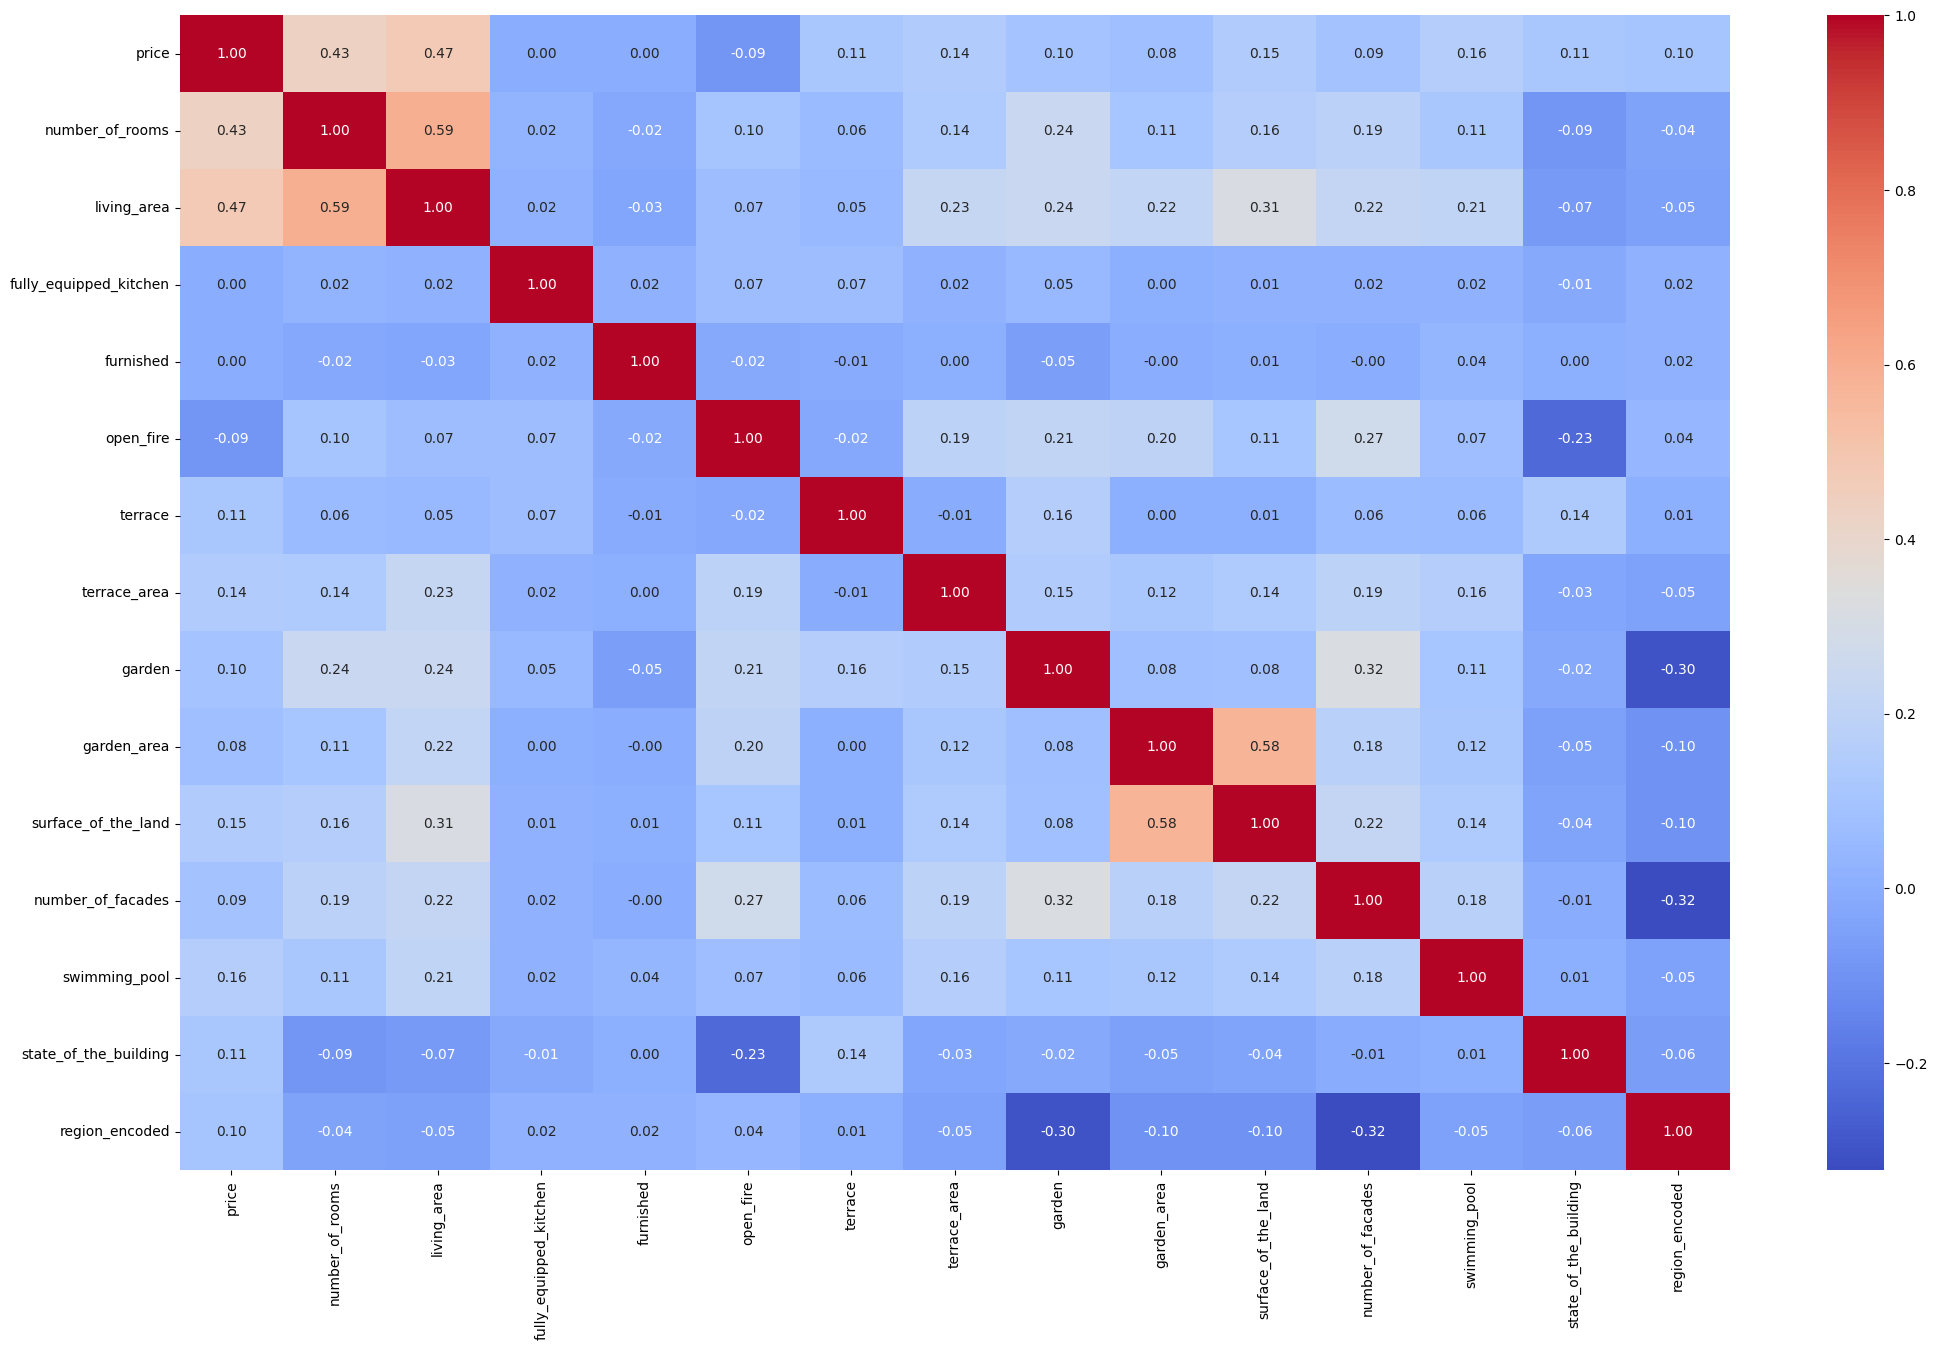

In [99]:
plt.figure(figsize=(25, 15))
sns.heatmap((df3[numeric_columns].corr()), annot = True, cmap = 'coolwarm', fmt = '.2f')


In [100]:
# What is we delete outliers? 
df4 = df3.copy()
df4.describe()

,price,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building,region_encoded
count,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0,12972.0
mean,436159.191181,2.947656,163.711687,2.08156,0.030836,0.354302,0.79078,24.992599,0.587265,748.60222,1042.476873,2.739362,0.030065,1.611625,0.962535
std,526010.49239,1.878374,130.624293,0.431912,0.172879,0.47832,0.406767,23.124511,0.492345,1743.523233,2527.731467,0.774257,0.170772,1.259896,0.802711
min,620.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
25%,230000.0,2.0,93.0,2.0,0.0,0.0,1.0,20.0,0.0,235.0,473.0,2.0,0.0,1.0,0.0
50%,333786.5,3.0,140.0,2.0,0.0,0.0,1.0,23.0,1.0,719.0,531.5,3.0,0.0,1.0,1.0
75%,489000.0,4.0,189.0,2.0,0.0,1.0,1.0,31.0,1.0,1218.0,1151.0,3.0,0.0,2.0,2.0
max,26000000.0,100.0,3000.0,3.0,1.0,1.0,1.0,1040.0,1.0,118000.0,101895.0,4.0,1.0,4.0,2.0


In [101]:
df4['surface_of_the_land'].describe(include='all')

count        12972.0
mean     1042.476873
std      2527.731467
min              1.0
25%            473.0
50%            531.5
75%           1151.0
max         101895.0
Name: surface_of_the_land, dtype: Float64

In [102]:
df4, outliers_surface_land = remove_outliers_iqr(df4, 'surface_of_the_land')

From column 'surface_of_the_land' the following number of outliers 587 were deleted
Range [-544.00, 2168.00]


In [103]:
df4['surface_of_the_land'].describe(include='all')

count       12385.0
mean     752.077755
std      467.726353
min             1.0
25%           473.0
50%           473.0
75%          1151.0
max          2168.0
Name: surface_of_the_land, dtype: Float64

In [104]:
outliers_surface_land

,url,zip_code,city,type_of_property,subtype_of_property,price,type_of_sale,number_of_rooms,living_area,fully_equipped_kitchen,...,property_subtype_master-house,property_subtype_mixed-building,property_subtype_penthouse,property_subtype_residence,property_subtype_studio,property_subtype_triplex,property_subtype_villa,sale_type_for sale,sale_type_in public sale,region_encoded
4,https://immovlan.be/en/detail/villa/for-sale/1...,1780,Wemmel,House,villa,1149000,for sale,5,396,2,...,False,False,False,False,False,False,True,True,False,0
36,https://immovlan.be/en/detail/villa/for-sale/1...,1150,Sint-Pieters-Woluwe,House,villa,2900000,for sale,5,988,2,...,False,False,False,False,False,False,True,True,False,2
88,https://immovlan.be/en/detail/residence/for-sa...,1380,Lasne,House,residence,1050000,for sale,5,430,2,...,False,False,False,True,False,False,False,True,False,1
147,https://immovlan.be/en/detail/cottage/for-sale...,7850,Enghien,Apartment,cottage,649000,for sale,5,245,2,...,False,False,False,False,False,False,False,True,False,1
155,https://immovlan.be/en/detail/residence/for-sa...,1420,Braine-l,House,residence,2595000,for sale,5,402,2,...,False,False,False,True,False,False,False,True,False,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13073,https://immovlan.be/en/detail/residence/for-sa...,2580,Beerzel,House,residence,590000,for sale,5,214,2,...,False,False,False,True,False,False,False,True,False,0
13086,https://immovlan.be/en/detail/residence/for-sa...,6924,Lomprez,House,residence,225000,for sale,6,206,2,...,False,False,False,True,False,False,False,True,False,1
13087,https://immovlan.be/en/detail/villa/for-sale/7...,7322,Ville-Pommeroeul,House,villa,1990000,for sale,4,536,2,...,False,False,False,False,False,False,True,True,False,1
13101,https://immovlan.be/en/detail/residence/for-sa...,8610,Kortemark,House,residence,425000,for sale,2,98,2,...,False,False,False,True,False,False,False,True,False,0


In [105]:
df4.describe()

,price,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building,region_encoded
count,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0,12385.0
mean,414718.535406,2.862818,154.312313,2.080985,0.030844,0.340896,0.788212,24.113847,0.570044,642.385789,752.077755,2.690028,0.022285,1.627291,0.975616
std,501656.94599,1.752074,107.641312,0.433551,0.172901,0.47403,0.408592,19.883112,0.495089,729.129293,467.726353,0.750485,0.147615,1.2689,0.811071
min,620.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
25%,229000.0,2.0,91.0,2.0,0.0,0.0,1.0,18.0,0.0,235.0,473.0,2.0,0.0,1.0,0.0
50%,325000.0,3.0,135.0,2.0,0.0,0.0,1.0,23.0,1.0,719.0,473.0,3.0,0.0,1.0,1.0
75%,469000.0,3.0,180.0,2.0,0.0,1.0,1.0,31.0,1.0,1119.0,1151.0,3.0,0.0,2.0,2.0
max,26000000.0,100.0,2700.0,3.0,1.0,1.0,1.0,865.0,1.0,61000.0,2168.0,4.0,1.0,4.0,2.0


In [106]:
df4, outlier_number_of_rooms = remove_outliers_iqr(df4, 'number_of_rooms')

From column 'number_of_rooms' the following number of outliers 1282 were deleted
Range [0.50, 4.50]


In [107]:
df4.describe()

,price,number_of_rooms,living_area,fully_equipped_kitchen,furnished,open_fire,terrace,terrace_area,garden,garden_area,surface_of_the_land,number_of_facades,swimming_pool,state_of_the_building,region_encoded
count,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0,11103.0
mean,379123.6165,2.556336,138.515086,2.080429,0.029361,0.336215,0.787175,23.710529,0.5485,643.925876,755.708817,2.680987,0.018193,1.671981,0.955958
std,440075.465722,0.911234,77.600592,0.429415,0.168825,0.472435,0.409324,19.926861,0.497665,730.902205,463.370311,0.740158,0.133656,1.28918,0.811746
min,620.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,1.0,0.0,0.0,0.0
25%,225000.0,2.0,90.0,2.0,0.0,0.0,1.0,17.0,0.0,235.0,473.0,2.0,0.0,1.0,0.0
50%,315000.0,3.0,127.0,2.0,0.0,0.0,1.0,23.0,1.0,719.0,473.0,3.0,0.0,1.0,1.0
75%,440000.0,3.0,170.0,2.0,0.0,1.0,1.0,31.0,1.0,1133.0,1151.0,3.0,0.0,2.0,2.0
max,26000000.0,4.0,1579.0,3.0,1.0,1.0,1.0,865.0,1.0,61000.0,2168.0,4.0,1.0,4.0,2.0


<Axes: >

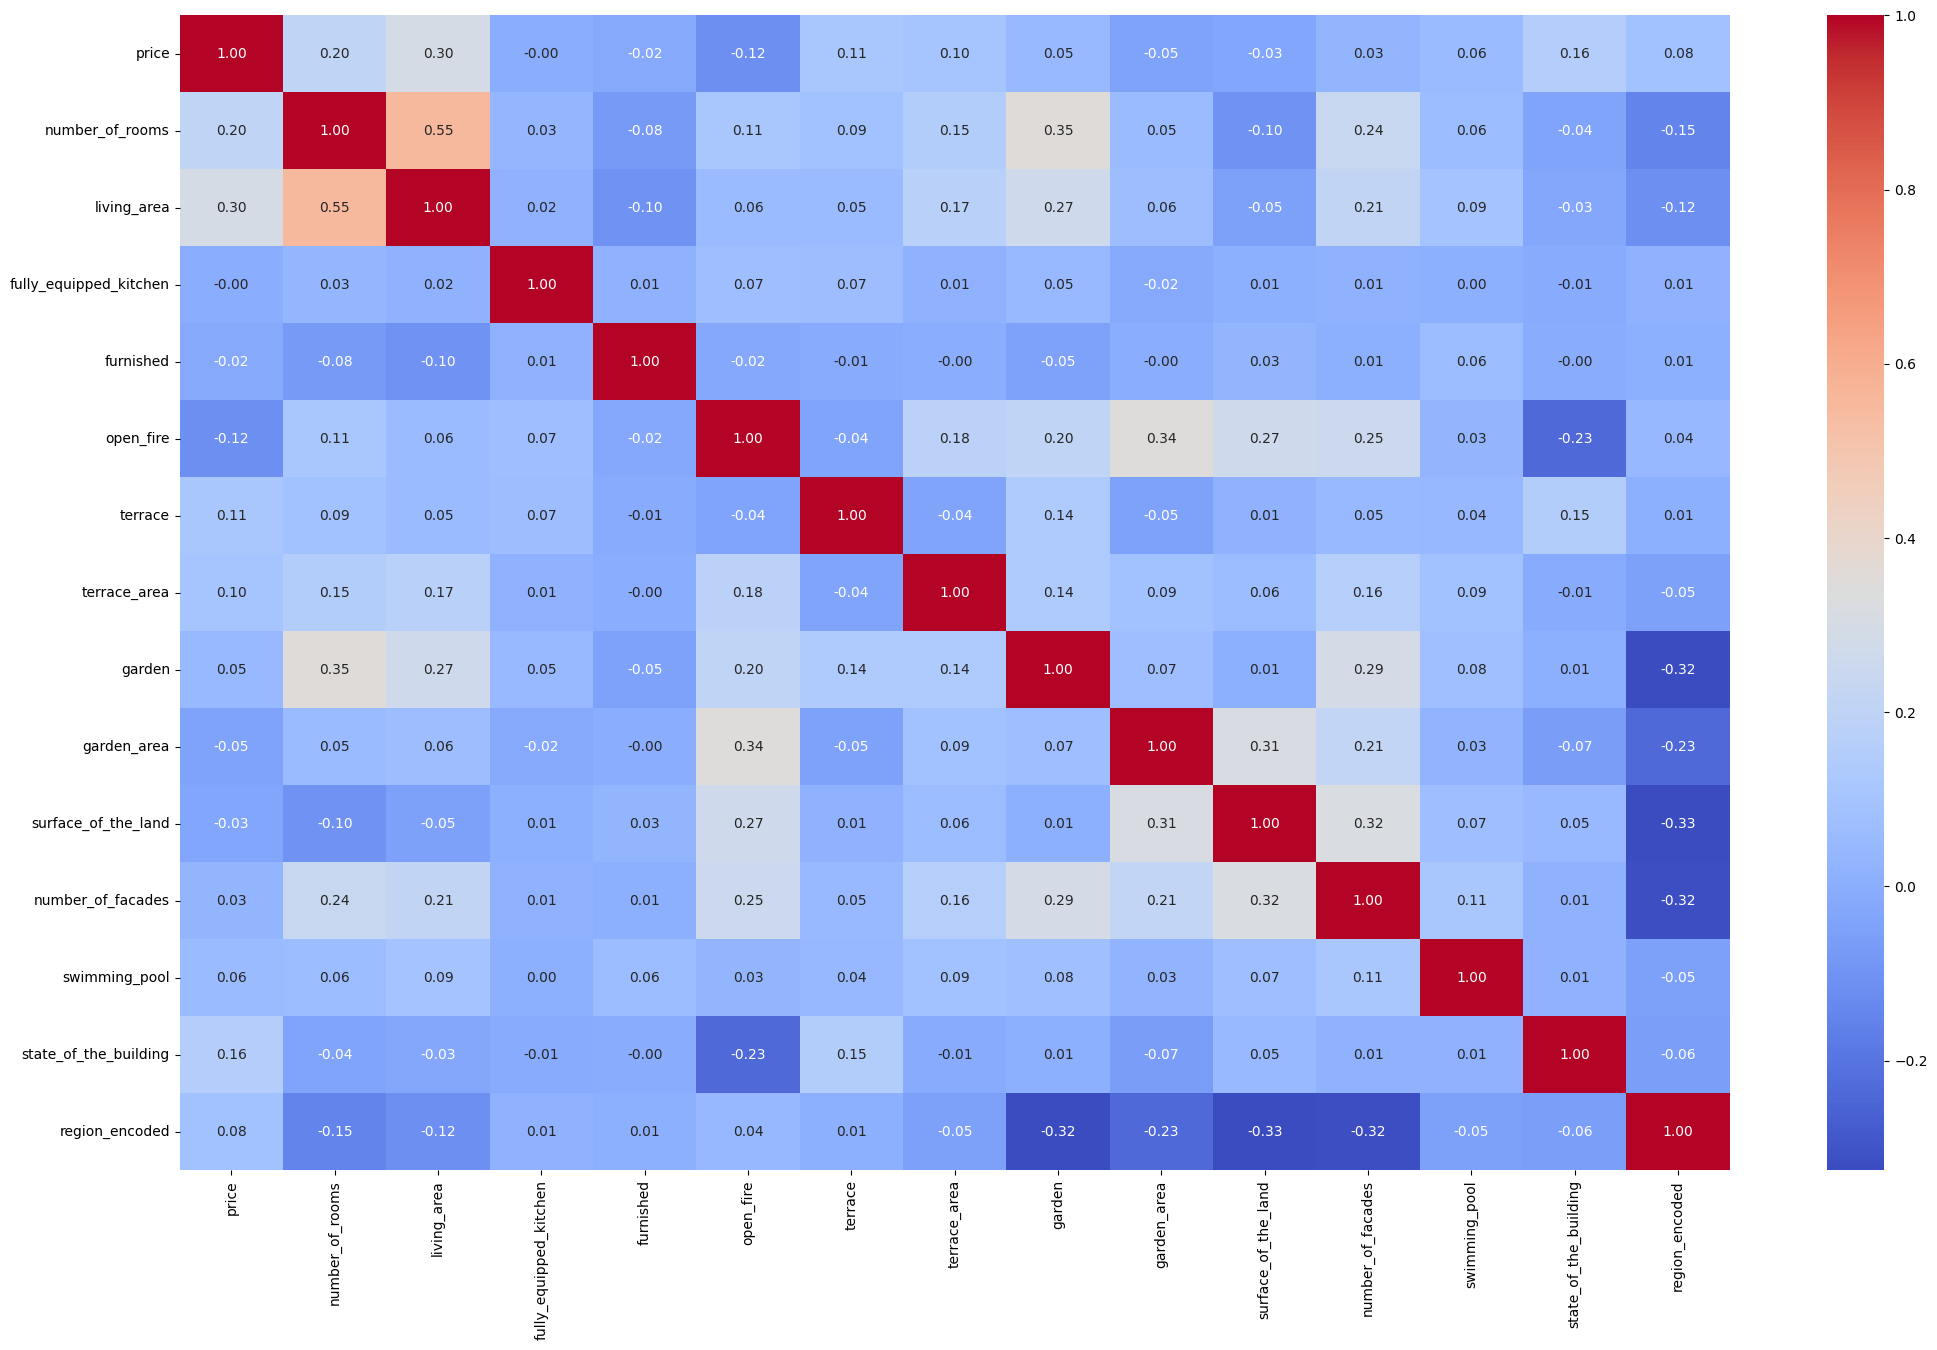

In [108]:
plt.figure(figsize=(25, 15))
sns.heatmap((df4[numeric_columns].corr()), annot = True, cmap = 'coolwarm', fmt = '.2f')